<a href="https://colab.research.google.com/github/refreshminht/actblue_skills_test/blob/main/ActBlue_st_ex2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
fec_filing = pd.read_csv('/content/drive/MyDrive/JOBS/ActBlue/Data_Analytics_Technical_FEC_Filing_Sample.csv')
fec_committee = pd.read_csv('/content/drive/MyDrive/JOBS/ActBlue/Data_Analytics_Technical_FEC_Committee_Data_2020.csv')

##Exploring the data and integrity checks

Below, I conduct integrity checks before analyzing a new datasets


In [ ]:
#Exploring the FEC filing sample dataset to gain familiarity with column names and their meanings
fec_filing

,fec_report_id,date_report_received,form_type,filer_committee_id_number,transaction_id,entity_type,contributor_last_name,contributor_first_name,contributor_street_1,contributor_city,contributor_state,contributor_zip_code,contribution_date,contribution_amount,contribution_aggregate,contribution_purpose_descrip,contributor_employer,contributor_occupation,memo_text_description
0,1385527,2020-02-21,SA11AI,C00401224,SA11AI_202581026,IND,CLICK,JANE,2720 N SWAN RD APT 12B,TUCSON,AZ,85712,2020-01-26,3.0,3.0,Earmark,SELF,MUSIC THERAPIST,Earmarked for MARK KELLY FOR SENATE (C00696526)
1,1391686,2020-03-21,SA11AI,C00401224,SA11AI_207544342,IND,KOONS,DAVE,5500 MILTON PLACE,AUSTELL,GA,30106,2020-02-10,27.0,1336.0,Earmark,TECHMAHINDRA,SOFTWARE DEVELOPER,Earmarked for BERNIE 2020 (C00696948)
2,1402724,2020-04-20,SA11AI,C00401224,SA11AI_222368496,IND,KREIMER,GINNY,9307-21ST AVE NW,SEATTLE,WA,98117,2020-03-25,7.0,7.0,Earmark,NOT EMPLOYED,NOT EMPLOYED,Earmarked for DEMOCRATIC NATIONAL COMMITTEE (C...
3,1385527,2020-02-21,SA11AI,C00401224,SA11AI_203910298,IND,RILEY,KOMARR,738 HUNTLY COURT,SCHAUMBURG,IL,60194,2020-01-30,5.0,5.0,Earmark,CONQUEROR TRANS,TRUCK DRIVER,"Earmarked for WARREN FOR PRESIDENT, INC. (C006..."
4,1385527,2020-02-21,SA11AI,C00401224,SA11AI_203208239,IND,DAMARLA,PRIYA,3001 NORTH SPAULDING AVENUE APT 2,CHICAGO,IL,60618,2020-01-28,2.7,2.7,Earmark,SOFTWARE RESEARCHERS INC.,DATA SCIENTIST,Earmarked for BERNIE 2020 (C00696948)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399995,1402724,2020-04-20,SA11AI,C00401224,SA11AI_223908629,IND,PIERCE,JONATHAN,365 N HALSTED ST APT 904,CHICAGO,IL,60661,2020-03-31,50.0,50.0,Earmark,NEXTCAPITAL INC,SOFTWARE DEVELOPER,Earmarked for BIDEN FOR PRESIDENT (C00703975)
399996,1402724,2020-04-20,SA11AI,C00401224,SA11AI_217430573,IND,SUNSHINE,SARA,23500 CRISTO REY DR UNIT 111B,CUPERTINO,CA,95014,2020-03-06,100.0,120.0,Earmark,NOT EMPLOYED,NOT EMPLOYED,Earmarked for BIDEN FOR PRESIDENT (C00703975)
399997,1391686,2020-03-21,SA11AI,C00401224,SA11AI_207610928,IND,CHODACKI,RICHARD,12814 S 38TH PL,PHOENIX,AZ,85044,2020-02-10,50.0,100.0,Earmark,CABLE ONE,NETWORK SECURITY ENG,Earmarked for BERNIE 2020 (C00696948)
399998,1391686,2020-03-21,SA11AI,C00401224,SA11AI_212843064,IND,HONS,CASEY,155 ROSEHIP RD,EASTSOUND,WA,98245,2020-02-25,5.0,7.7,Earmark,ISLAND SKYLINE,TREE WORKER,Earmarked for BERNIE 2020 (C00696948)


In [ ]:
#Viewing data types of columns
print(fec_filing.info())

#Exploring the summary table
print(fec_filing[['contribution_amount','contribution_aggregate']].describe())

#Checking sum of NA values
print(fec_filing.isnull().sum())

#Duplication check, there are none
print('Dupes:', fec_filing.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   fec_report_id                 400000 non-null  int64  
 1   date_report_received          400000 non-null  object 
 2   form_type                     400000 non-null  object 
 3   filer_committee_id_number     400000 non-null  object 
 4   transaction_id                400000 non-null  object 
 5   entity_type                   400000 non-null  object 
 6   contributor_last_name         399981 non-null  object 
 7   contributor_first_name        399996 non-null  object 
 8   contributor_street_1          400000 non-null  object 
 9   contributor_city              399999 non-null  object 
 10  contributor_state             400000 non-null  object 
 11  contributor_zip_code          400000 non-null  object 
 12  contribution_date             400000 non-nul

In [ ]:
#extracting cmte_id from memo_text_description
fec_filing['cmte_id'] = fec_filing['memo_text_description'].str.extract(r'\(([^)]+)\)')

In [ ]:
fec_committee

,bg_cycle,cmte_id,cmte_nm,tres_nm,cmte_st1,cmte_st2,cmte_city,cmte_st,cmte_zip,cmte_dsgn,cmte_tp,cmte_pty_affiliation,cmte_filing_freq,org_tp,connected_org_nm,cand_id
0,2020,C00745828,JAWAD AGADIR FOR PRESIDENT,"CEO, CEO",3 JAWAD ROAD,NaN,JAWAD TOWN,IN,13337,U,U,NaN,Q,NaN,NONE,NaN
1,2020,C00755884,THE SAVIOR OF MEN,"SOLOMON, DEANDRE LAMONT SOLOMON",16728 BILTMORE,NaN,DETROIT,MI,48235,P,P,IND,Q,NaN,NONE,P00017111
2,2020,C00756072,PLEASE MAKE TURTLE ISLAND A COUNCIL OF SACRED ...,"GUMP, BRANDY MARIE MS.",58 OLD LEICESTER,NaN,ASHEVILLE,NC,28804,U,N,NaN,Q,NaN,NONE,NaN
3,2020,C00756346,FRIENDS OF BETSY PAULINE ELGAR COMMITTEE,BETSY PAULINE ELGAR,8914 VETERANS DRIVE SW STE A,NaN,LAKEWOOD,WA,98498,P,P,CON,Q,NaN,BETSY PAULINE ELGAR REAL ESTATES,P20003851
4,2020,C00751628,GEORGE WASHINGTON 2020,"LEE, DONNIE GRAY",3200 MT VERNON MEMORIAL HWY,NaN,MT VERNON,VA,22121,P,P,IND,Q,NaN,NONE,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18318,2020,C90020066,ACTION FOR A PROGRESSIVE FUTURE,NaN,1500 W. EL CAMINO AVENUE #370,NaN,SACRAMENTO,CA,95833,U,I,NaN,Q,NaN,NaN,NaN
18319,2020,C90020702,BOLD ALLIANCE,NaN,208 BURLINGTON AVE.,STE. 103 BOX 325,HASTINGS,NB,68901,U,I,NaN,Q,NaN,NaN,NaN
18320,2020,C90019266,PIONEER VALLEY DEMOCRATIC SOCIALISTS OF AMERICA,NaN,PO 4935,NaN,HOLYOKE,MA,01041,U,I,NaN,Q,NaN,NaN,NaN
18321,2020,C90019936,PONTIAC POLICY ACTION FUND,NaN,91 N. SAGINAW ST. G-109,NaN,PONTIAC,MI,48342,U,I,NaN,Q,NaN,NaN,NaN


In [ ]:
#Viewing data types of columns
print(fec_committee.info())

#Checking sum of NA values
print(fec_committee.isnull().sum())

#Duplication check, there are none
print('Dupes:', fec_committee.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18323 entries, 0 to 18322
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   bg_cycle              18323 non-null  int64 
 1   cmte_id               18323 non-null  object
 2   cmte_nm               18321 non-null  object
 3   tres_nm               17592 non-null  object
 4   cmte_st1              18312 non-null  object
 5   cmte_st2              4529 non-null   object
 6   cmte_city             18313 non-null  object
 7   cmte_st               18315 non-null  object
 8   cmte_zip              18310 non-null  object
 9   cmte_dsgn             18318 non-null  object
 10  cmte_tp               18318 non-null  object
 11  cmte_pty_affiliation  7839 non-null   object
 12  cmte_filing_freq      18323 non-null  object
 13  org_tp                3381 non-null   object
 14  connected_org_nm      9306 non-null   object
 15  cand_id               6780 non-null 

## Merging datasets


Below I merge the fec_filing and fec_commmittee dataset on the committee id

In [ ]:
#mergining on cmte_id because both datasets have the shared column
fec_info = pd.merge(fec_filing, fec_committee, on = 'cmte_id')

In [ ]:
fec_info

,fec_report_id,date_report_received,form_type,filer_committee_id_number,transaction_id,entity_type,contributor_last_name,contributor_first_name,contributor_street_1,contributor_city,...,cmte_city,cmte_st,cmte_zip,cmte_dsgn,cmte_tp,cmte_pty_affiliation,cmte_filing_freq,org_tp,connected_org_nm,cand_id
0,1385527,2020-02-21,SA11AI,C00401224,SA11AI_202581026,IND,CLICK,JANE,2720 N SWAN RD APT 12B,TUCSON,...,TUCSON,AZ,85726,P,S,DEM,Q,NaN,MARK KELLY VICTORY FUND,S0AZ00350
1,1391686,2020-03-21,SA11AI,C00401224,SA11AI_207544342,IND,KOONS,DAVE,5500 MILTON PLACE,AUSTELL,...,BURLINGTON,VT,05402,P,P,DEM,M,NaN,NaN,P60007168
2,1402724,2020-04-20,SA11AI,C00401224,SA11AI_222368496,IND,KREIMER,GINNY,9307-21ST AVE NW,SEATTLE,...,WASHINGTON,DC,20003,U,Y,DEM,M,NaN,DEMOCRATIC GRASSROOTS VICTORY FUND,NaN
3,1385527,2020-02-21,SA11AI,C00401224,SA11AI_203910298,IND,RILEY,KOMARR,738 HUNTLY COURT,SCHAUMBURG,...,FOXBORO,MA,02035,P,P,DEM,Q,NaN,NaN,P00009621
4,1385527,2020-02-21,SA11AI,C00401224,SA11AI_203208239,IND,DAMARLA,PRIYA,3001 NORTH SPAULDING AVENUE APT 2,CHICAGO,...,BURLINGTON,VT,05402,P,P,DEM,M,NaN,NaN,P60007168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314995,1402724,2020-04-20,SA11AI,C00401224,SA11AI_223908629,IND,PIERCE,JONATHAN,365 N HALSTED ST APT 904,CHICAGO,...,PHILADELPHIA,PA,19102,P,P,DEM,M,NaN,BIDEN VICTORY FUND,P80000722
314996,1402724,2020-04-20,SA11AI,C00401224,SA11AI_217430573,IND,SUNSHINE,SARA,23500 CRISTO REY DR UNIT 111B,CUPERTINO,...,PHILADELPHIA,PA,19102,P,P,DEM,M,NaN,BIDEN VICTORY FUND,P80000722
314997,1391686,2020-03-21,SA11AI,C00401224,SA11AI_207610928,IND,CHODACKI,RICHARD,12814 S 38TH PL,PHOENIX,...,BURLINGTON,VT,05402,P,P,DEM,M,NaN,NaN,P60007168
314998,1391686,2020-03-21,SA11AI,C00401224,SA11AI_212843064,IND,HONS,CASEY,155 ROSEHIP RD,EASTSOUND,...,BURLINGTON,VT,05402,P,P,DEM,M,NaN,NaN,P60007168


## Analysis

Below, I created two graphs that show:

1.   The top 10 congressional committees with the most out-of-state contributions between February and April 2020.
2.   The top 10 donor occupations contributing the most out-of-state donations to these committees.


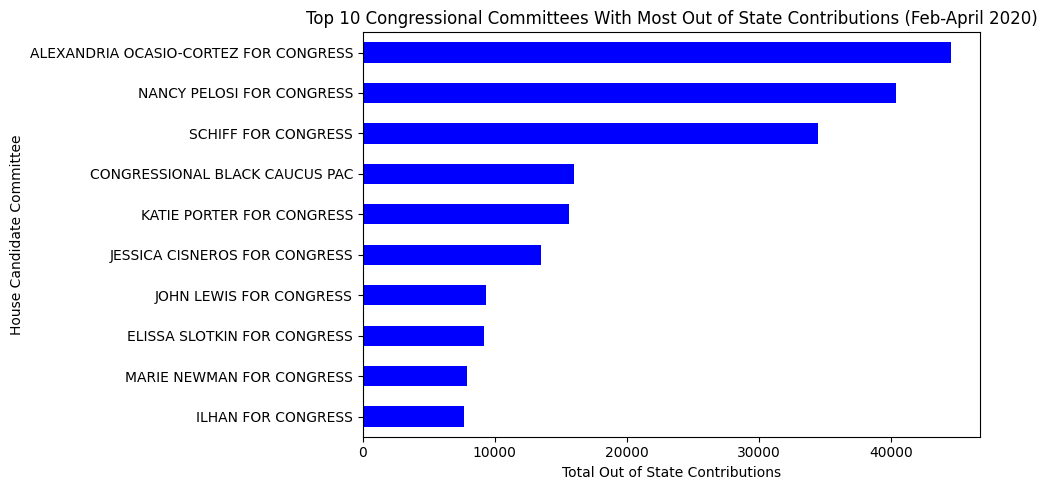

In [ ]:
import matplotlib.pyplot as plt

#filtering out of state donations
out_of_state = fec_info[fec_info['contributor_state'] != fec_info['cmte_st']]

#filtering for committees that contain 'CONGRESS'
congress_committees = out_of_state[out_of_state['cmte_nm'].str.contains('CONGRESS', na=False)]

#group by committee name and sum the contributions
top_congress_committees = (congress_committees.groupby('cmte_nm')['contribution_amount']
    .sum().sort_values(ascending=False).head(10))

#plotting top 10 dem congressional committees by out of state contributions
top_senate_committees.plot(kind='barh', figsize=(10, 5), color='blue')
plt.xlabel('Total Out of State Contributions')
plt.ylabel('House Candidate Committee')
plt.title('Top 10 Congressional Committees With Most Out of State Contributions (Feb-April 2020)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

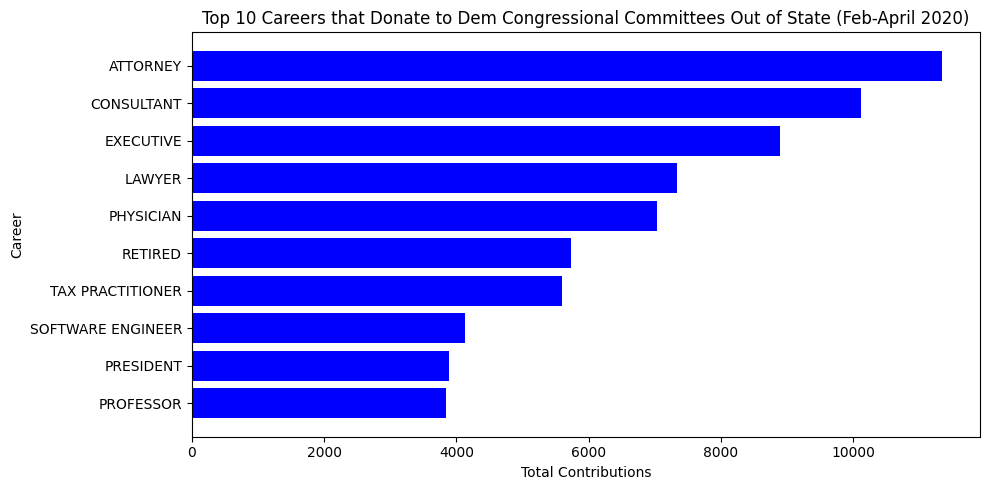

In [ ]:
#filtering out of state donations
out_of_state = fec_info[fec_info['contributor_state'] != fec_info['cmte_st']]

#filtering to democratic congressional committees
dem_congress_committees = out_of_state[
    out_of_state['cmte_nm'].str.contains('CONGRESS', case=False, na=False) &
    ~out_of_state['cmte_nm'].str.contains('CONGRESSIONAL', case=False, na=False)]

#removing "NOT EMPLOYED" and "NONE" occupation
dem_congress_committees = dem_congress_committees[
    ~dem_congress_committees['contributor_occupation'].isin(['NOT EMPLOYED', 'NONE'])]

#grouping by occupation
career_donations = (
    dem_congress_committees.groupby('contributor_occupation')['contribution_amount']
    .sum().reset_index().sort_values(by='contribution_amount', ascending=False).head(10))

#plotting top 10 careers that donate to dems out of state
plt.figure(figsize=(10, 5))
plt.barh(career_donations['contributor_occupation'], career_donations['contribution_amount'], color='blue')
plt.xlabel('Total Contributions')
plt.ylabel('Career')
plt.title('Top 10 Careers that Donate to Dem Congressional Committees Out of State (Feb-April 2020)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()